# Étape 2 — Entraînement de l'auto-encodeur (`pill`)

TP B6, partie 2. Entraîner sur les seules pièces saines (cible = entrée), suivi
MLflow.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from indusense.vision.model import build_autoencoder
from indusense.vision.train import MODEL_PATH, build_training_set, save_model, train_autoencoder

IMAGE_SIZE = (256, 256)
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Décision — hyperparamètres d'entraînement

**Décision** : perte **MSE** pour le run retenu (celui sauvegardé et utilisé dans les
notebooks suivants), un second run en perte **SSIM** à titre de comparaison. Train
augmenté ×5 (image originale + 4 versions augmentées par le pipeline de la partie 1),
validation saine non augmentée. `EarlyStopping` sur `val_loss` plutôt qu'un nombre
d'epochs fixe.

### Pourquoi MSE plutôt que SSIM comme run retenu

**L'argument décisif — cohérence entre ce que le modèle optimise et ce qu'on va
mesurer ensuite.** Le score d'anomalie qui sert dans tout le reste du TP (notebook 05,
`anomaly.py`) est l'erreur de reconstruction **MSE** moyennée sur l'image. Ce score
n'existe pas encore ici — seule la perte d'entraînement (MSE ou SSIM selon le run) est
calculée dans ce notebook — mais on sait déjà qu'il sera basé sur la MSE, donc on peut
anticiper quel modèle lui sera cohérent :
- un modèle **entraîné avec la perte MSE** est *directement* optimisé pour minimiser
  cette même quantité sur les pièces saines : la fonction utilisée ensuite pour
  distinguer sain/défaut est exactement celle que l'entraînement a cherché à réduire
  — pas de décalage ;
- un modèle **entraîné avec la perte SSIM** optimise un critère différent (similarité
  structurelle, volontairement insensible aux décalages de luminance/contraste) — rien
  ne garantit qu'un tel modèle ait, en prime, une MSE de reconstruction basse et bien
  calibrée sur les saines. Le retenir comme modèle final introduirait un vrai
  décalage : entraîné pour un objectif, mesuré sur un autre.

Le run MSE n'a structurellement pas ce problème, puisqu'il optimise exactement ce
qu'on mesurera après.

**Deux arguments secondaires, qui affaiblissent l'intérêt de SSIM ici sans l'invalider
en principe :**
1. **L'avantage théorique de SSIM se dilue dans notre pipeline** : SSIM est en
   principe plus sensible aux altérations de texture locale (pertinent pour des
   défauts comme `crack`/`scratch`) — mais le score d'anomalie (`image_scores`,
   calculé au notebook 05) moyenne l'erreur sur l'image **entière** (256×256), pas sur
   des fenêtres locales. À ce niveau d'agrégation globale, un défaut ponctuel pèse peu
   dans une moyenne sur 65 536 pixels, quelle que soit la perte utilisée à
   l'entraînement — le notebook 05 le confirme : le chevauchement sain/défaut observé
   montre que beaucoup de petits défauts ne remontent pas au niveau du score global.
   SSIM ne montrerait tout son intérêt exploité en carte locale par fenêtre, pas comme
   simple substitut de la perte globale.
2. **Coût mesuré, pas seulement anticipé** : une fois les deux runs exécutés, le run
   SSIM a pris 1658 s contre 1085 s pour MSE (+53 %) pour un nombre d'epochs
   comparable — un différentiel réel qui pèse en faveur de MSE comme run par défaut
   si l'on doit réentraîner régulièrement.

**Conclusion** : SSIM n'est pas rejeté — l'énoncé demande explicitement de l'essayer,
et le run est conservé comme point de comparaison documenté (utile pour juger si son
coût supplémentaire se justifierait avec un score exploitant des cartes d'erreur
locales plutôt qu'une moyenne globale). Mais ce n'est pas le modèle retenu,
précisément parce que MSE est le seul choix qui garantit l'alignement entre ce que le
modèle apprend et ce qu'on mesure ensuite pour détecter une anomalie.

### Pourquoi les autres choix

- **Augmentation ×5** : le jeu de saines est minuscule (227 images après réservation
  de la validation) — l'augmenter artificiellement limite le risque que le modèle
  apprenne par cœur ces 227 exemples plutôt qu'une notion générale de « normal ».
- **`EarlyStopping`** : avec un jeu aussi petit, le nombre d'epochs optimal n'est pas
  connu à l'avance ; s'arrêter sur `val_loss` évite de choisir arbitrairement.

In [2]:
x_train, x_val = build_training_set(image_size=IMAGE_SIZE, n_aug=4)
model = build_autoencoder(image_size=IMAGE_SIZE, latent_channels=16)

lines = [
    f"- **Train (avec augmentation)** : {x_train.shape[0]} images.",
    f"- **Validation (saines, non augmentées)** : {x_val.shape[0]} images.",
]
display(Markdown(chr(10).join(lines)))

- **Train (avec augmentation)** : 1135 images.
- **Validation (saines, non augmentées)** : 40 images.

In [3]:
model, history, duration = train_autoencoder(
    model,
    x_train,
    x_val,
    loss="mse",
    epochs=50,
    batch_size=32,
    learning_rate=1e-3,
    run_name="autoencoder-mse",
    log_mlflow=True,
)

display(Markdown(f"- **Durée d'entraînement (run MSE)** : {duration:.1f} s."))

Epoch 1/50


36/36 - 22s - 619ms/step - loss: 0.1127 - val_loss: 0.0738


Epoch 2/50


36/36 - 22s - 599ms/step - loss: 0.0278 - val_loss: 0.0063


Epoch 3/50


...

Epoch 50/50


36/36 - 23s - 635ms/step - loss: 3.0842e-04 - val_loss: 2.6205e-04


2026/07/21 14:51:43 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


2026/07/21 14:52:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


- **Durée d'entraînement (run MSE)** : 1085.0 s.

## Livrable — courbe d'apprentissage

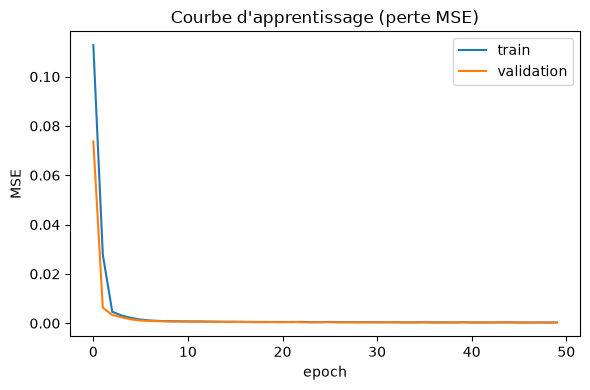

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["loss"], label="train")
ax.plot(history.history["val_loss"], label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("Courbe d'apprentissage (perte MSE)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_courbes_apprentissage.png", dpi=150)
plt.show()

## Livrable — exemples de reconstruction (saines de validation)

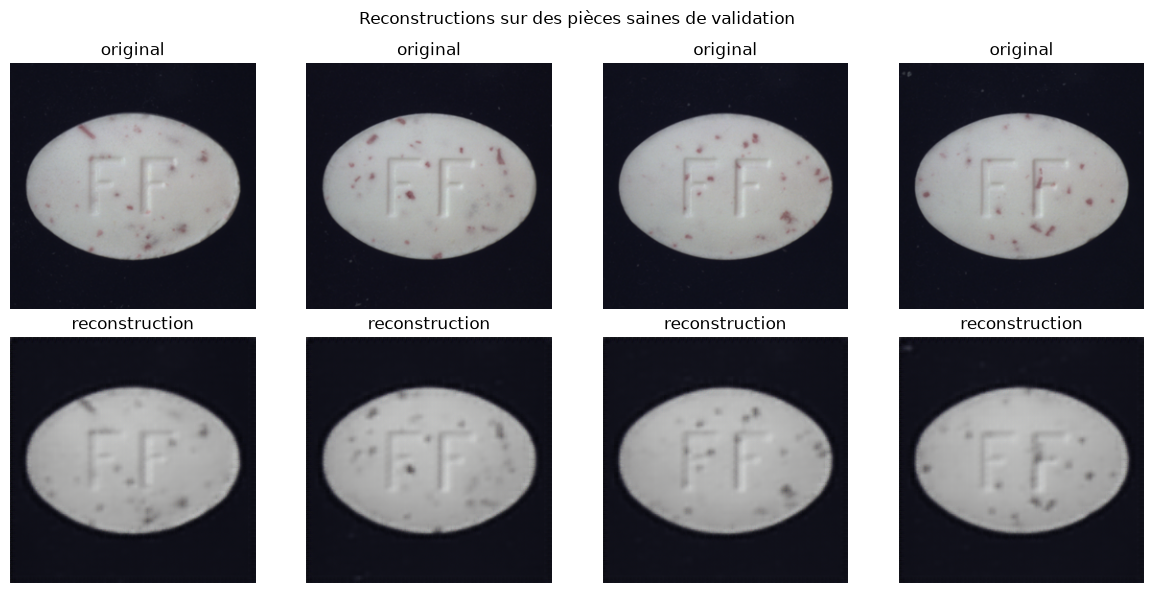

In [5]:
n_examples = 4
sample = x_val[:n_examples]
reconstructions = model.predict(sample, verbose=0)

fig, axes = plt.subplots(2, n_examples, figsize=(3 * n_examples, 6))
for i in range(n_examples):
    axes[0, i].imshow(sample[i])
    axes[0, i].set_title("original")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i])
    axes[1, i].set_title("reconstruction")
    axes[1, i].axis("off")
fig.suptitle("Reconstructions sur des pièces saines de validation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_reconstructions.png", dpi=150)
plt.show()

## Décision — comparaison avec une perte SSIM

**Décision** : entraîner un second modèle, architecture identique, perte SSIM au lieu
de MSE, journalisé dans un run MLflow séparé (`autoencoder-ssim`) — sans remplacer le
modèle retenu pour la suite du TP.

**Pourquoi** : l'énoncé invite explicitement à « essayer aussi SSIM ». Les valeurs de
perte MSE et `1 - SSIM` ne vivent pas sur la même échelle : les comparer directement
n'a pas de sens. Ce qui est interprétable ici, c'est l'écart train/val **au sein** de
chaque run (indice de sur-apprentissage), pas une comparaison de valeur absolue entre
les deux pertes. Un arbitrage définitif MSE vs SSIM se ferait sur la capacité de
détection réelle (AUROC, étape 4), pas sur la courbe de perte.

In [6]:
model_ssim = build_autoencoder(image_size=IMAGE_SIZE, latent_channels=16)
model_ssim, history_ssim, duration_ssim = train_autoencoder(
    model_ssim,
    x_train,
    x_val,
    loss="ssim",
    epochs=50,
    batch_size=32,
    learning_rate=1e-3,
    run_name="autoencoder-ssim",
    log_mlflow=True,
)

lines = [
    f"- **Run MSE** : perte train={history.history['loss'][-1]:.4f}, "
    f"val={history.history['val_loss'][-1]:.4f}, durée={duration:.1f} s.",
    f"- **Run SSIM** : perte (`1 - SSIM`) train={history_ssim.history['loss'][-1]:.4f}, "
    f"val={history_ssim.history['val_loss'][-1]:.4f}, durée={duration_ssim:.1f} s.",
    "- Ces deux valeurs de perte ne sont **pas comparables entre elles** (échelles "
    "différentes) — seul l'écart train/val de chaque run est interprétable ici. La "
    "**durée**, elle, est directement comparable entre les deux runs.",
]
display(Markdown(chr(10).join(lines)))

Epoch 1/50


36/36 - 34s - 941ms/step - loss: 0.5479 - val_loss: 0.5489


Epoch 2/50


36/36 - 32s - 876ms/step - loss: 0.5167 - val_loss: 0.4814


Epoch 3/50


...

36/36 - 29s - 813ms/step - loss: 0.0245 - val_loss: 0.0294


2026/07/21 15:20:12 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


2026/07/21 15:20:56 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\patri\AppData\Local\Temp\tmpbfetvn0l\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


2026/07/21 15:20:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


- **Run MSE** : perte train=0.0003, val=0.0003, durée=1085.0 s.
- **Run SSIM** : perte (`1 - SSIM`) train=0.0245, val=0.0294, durée=1658.0 s.
- Ces deux valeurs de perte ne sont **pas comparables entre elles** (échelles différentes) — seul l'écart train/val de chaque run est interprétable ici. La **durée**, elle, est directement comparable entre les deux runs.

## Livrable — sauvegarde du modèle retenu (perte MSE)

In [7]:
save_model(model)
display(Markdown(f"- **Modèle sauvegardé** : `{MODEL_PATH}`"))

- **Modèle sauvegardé** : `D:\ProjetsIA\AELION_Deep_Learning_IA\artifacts\ml\models\autoencoder_pill.keras`